In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import cv2
import matplotlib.pyplot as plt
from google.colab import files

In [ ]:
model = models.Sequential()

# Encoder
model.add(layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(128,128,3)))
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Conv2D(64, (3,3), activation='relu', padding='same'))
model.add(layers.MaxPooling2D((2,2)))

# Decoder
model.add(layers.Conv2DTranspose(64, (3,3), strides=2, padding='same', activation='relu'))
model.add(layers.Conv2DTranspose(32, (3,3), strides=2, padding='same', activation='relu'))

# Output mask
model.add(layers.Conv2D(1, (1,1), activation='sigmoid', padding='same'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [ ]:
uploaded = files.upload()

Saving images.webp to images.webp


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


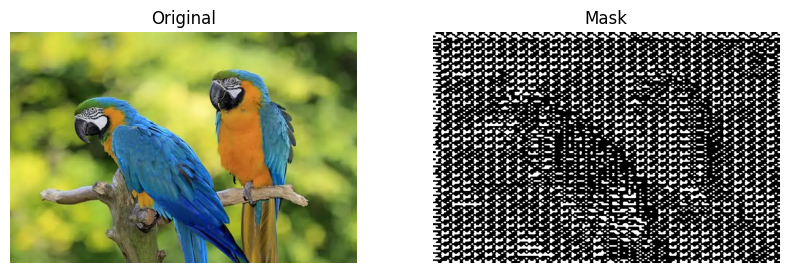

In [ ]:
for img_name in uploaded.keys():

    # 1. Read image
    img = cv2.imread(img_name)

    # Keep original for display
    original = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # 2. Preprocess for model
    img_resized = cv2.resize(img, (128,128))
    img_resized = img_resized.astype('float32') / 255.0
    img_resized = np.expand_dims(img_resized, axis=0)

    # 3. Prediction (FIXED)
    pred = model.predict(img_resized)[0]

    # 4. Create mask
    mask = (pred > 0.5).astype(np.uint8)

    # 5. Resize mask back to original size
    mask = cv2.resize(mask, (original.shape[1], original.shape[0]))

    # 6. Create colored mask
    colored_mask = np.zeros_like(original)
    colored_mask[mask == 1] = [0, 255, 0]   # green

    # 7. Overlay
    overlay = cv2.addWeighted(original, 0.7, colored_mask, 0.3, 0)

    # 8. Display
    plt.figure(figsize=(10,3))

    plt.subplot(1,2,1)
    plt.title("Original")
    plt.imshow(original)
    plt.axis('off')

    plt.subplot(1,2,2)
    plt.title("Mask")
    plt.imshow(mask, cmap='gray')
    plt.axis('off')

    plt.show()